# Telco Customer Churn — Exploratory Data Analysis

**Objective:** understand who churns, why, and which features carry the strongest signal —
this analysis feeds directly into the feature engineering and modeling notebook.

**Dataset:** IBM/Kaggle Telco Customer Churn (7,043 raw rows; one row per customer).


### Import Libraries

In [1]:

import pandas as pd
import numpy as np
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import gc
import time
from itertools import combinations
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import TargetEncoder
from scipy.stats import rankdata
from scipy.optimize import minimize, Bounds
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
#Visualization
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', 100)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

### Clean Data

In [2]:
def wrangle(filepath):
    df=pd.read_csv(filepath)
    #Convert 'Total Charges' from object to numeric
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce') #Total Charges should be a float not an object
    #Drop unwanted columns
    df=df.drop(columns=['customerID'])
    #Drop null values
    df=df.dropna()
    return df

### Load & Inspect Data

Apply the cleaning function, then check shape, columns, and dtypes before any visual analysis.

In [3]:
df=wrangle("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

In [6]:
df.shape


(7032, 20)

In [7]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Summary — Load & Clean:**
- 7,043 raw rows → **7,032 rows** after dropping nulls (11 rows had blank `TotalCharges`, all with `tenure == 0`)
- 20 columns: 16 categorical/object, 2 integer (`SeniorCitizen`, `tenure`), 2 float (`MonthlyCharges`, `TotalCharges`)
- No further missing values remain
- `customerID` dropped (identifier, not predictive)


### Feature Category Definitions

Group columns into demographic, service, account, and billing buckets — used throughout the plots below to keep the analysis organized.

In [8]:
# Define demographic features
demographic_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents"
]

# Define service-related features
service_features = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

# Define account-related features
account_features = [
    "tenure",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

# Define billing-related features
billing_features = [
    "MonthlyCharges",
    "TotalCharges"
]

In [9]:
#Convert target variable into binary values  
# df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1}).astype(int)
# df.head()

## Univariate Analysis: Target Variable

### Churn Distribution
How imbalanced is the target?

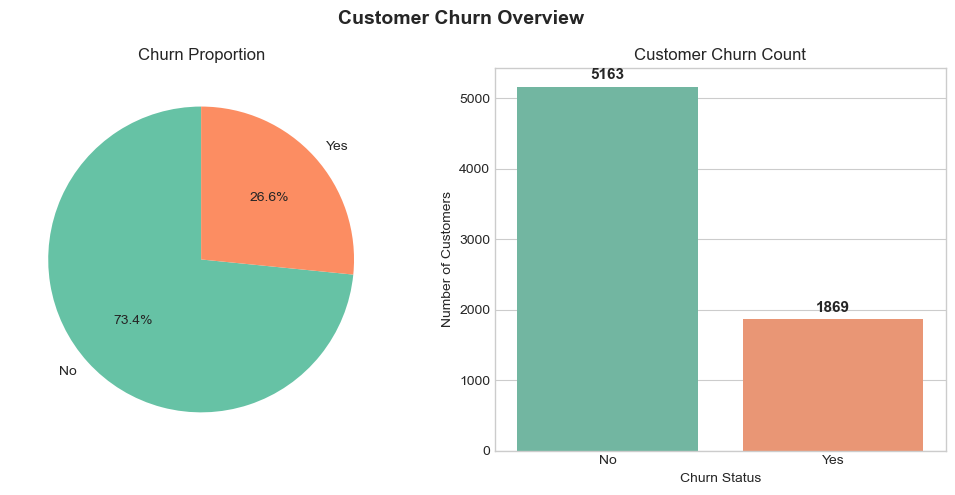

In [10]:
# Calculate churn distribution
churn_stats = df['Churn'].value_counts()

# Initialize subplots (1 row, 2 columns)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Plot Pie Chart on the first axis (ax[0])
ax[0].pie(
    churn_stats,
    labels=["No", "Yes"],
    autopct='%1.1f%%',          # Adds percentages to the slices (~26.5% vs 73.5%)
    startangle=90,              # Clean starting angle
    colors=sns.color_palette("Set2")
)
ax[0].set_title("Churn Proportion")

# Plot Countplot on the second axis (ax[1])
sns.countplot(
    data=df,
    x="Churn",
    hue="Churn",
    ax=ax[1],                   # Explicitly direct to the second subplot
    palette="Set2",
    legend=False                
)
ax[1].set_title("Customer Churn Count")
ax[1].set_xlabel("Churn Status")
ax[1].set_xticks([0,1])
ax[1].set_xticklabels(['No','Yes'])
ax[1].set_ylabel("Number of Customers")

# Add Value Labels Above the Bars
for container in ax[1].containers:
    ax[1].bar_label(container, padding=3, fontsize=11, fontweight='bold')
# Global layout adjustments
fig.suptitle("Customer Churn Overview", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


**Summary:** churn is imbalanced — roughly **1 in 4 customers churn** (~27% Yes / 73% No).
This matters for modeling later: accuracy alone will be misleading, and a stratified split plus
class-weighting (or resampling) will be needed to avoid the model just predicting "No" for everyone.


### Demographic Feature Distributions
`gender`, `SeniorCitizen`, `Partner`, `Dependents`

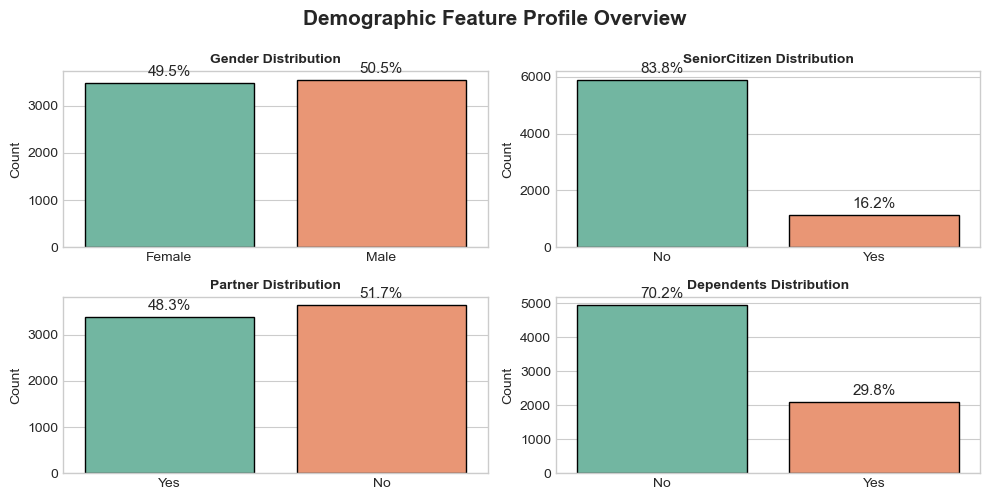

In [11]:
demographic_features = ["gender", "SeniorCitizen", "Partner", "Dependents"]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 5))
axes = axes.flatten()

for ax, feature in zip(axes, demographic_features):
    sns.countplot(
        data=df,
        x=feature,
        hue=feature,
        palette="Set2",
        edgecolor="black",
        legend=False, 
        ax=ax
    )

    # Add percentage labels relative to the total dataset size
    for container in ax.containers:
        ax.bar_label(
            container,
            labels=[f"{x / len(df) * 100:.1f}%" for x in container.datavalues],
            fontsize=11,
            padding=3
        )

    ax.set_title(f"{feature.capitalize()} Distribution", fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count')

    # Checklist #2 Correction: Explicitly map the 0/1 numeric labels to friendly names
    if feature == "SeniorCitizen":
        ax.set_title("SeniorCitizen Distribution", fontsize=10, fontweight='bold')
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["No", "Yes"])
        
fig.suptitle('Demographic Feature Profile Overview', fontsize=15, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()


### Service Feature Distributions
All internet/phone add-on service columns. Note the recurring **"No internet service"** category across several columns — these rows are the customers with no internet plan at all, not a distinct opt-out choice, so it's worth remembering these categories are duplicated across features rather than independent signals.

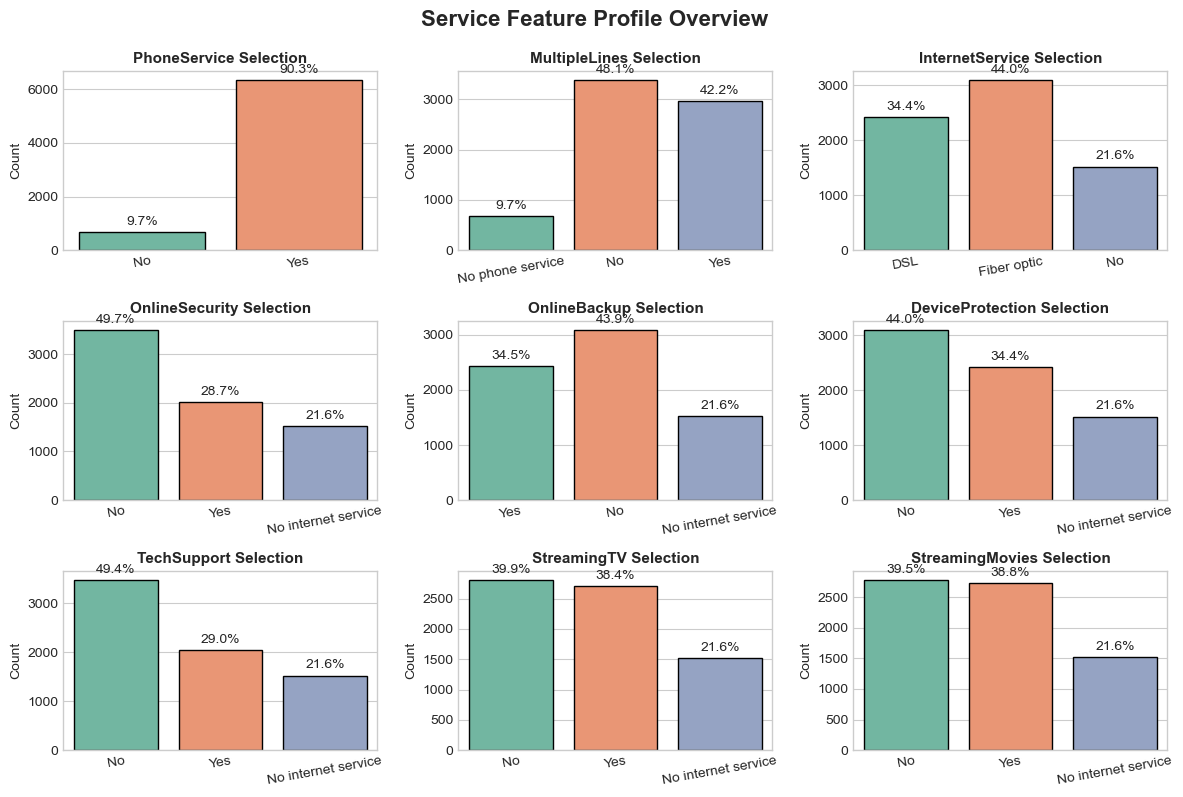

In [12]:
service_features = [
    "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity", 
    "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"
]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 8))
axes = axes.flatten()

for ax, feature in zip(axes, service_features):
    sns.countplot(
        data=df,
        x=feature,
        hue=feature,
        palette="Set2",
        edgecolor="black",
        legend=False, 
        ax=ax
    )

    # Add overall sample percentage metrics above columns
    for container in ax.containers:
        ax.bar_label(
            container,
            labels=[f"{x / len(df) * 100:.1f}%" for x in container.datavalues],
            fontsize=10,
            padding=3
        )

    # Checklist #4: Visually observe the weight of "No internet service" duplicates
    ax.set_title(f"{feature} Selection", fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=10) # Rotates small sub-labels slightly to avoid overlap

fig.suptitle('Service Feature Profile Overview', fontsize=16, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()


### Account & Contract Feature Distributions
`tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod`

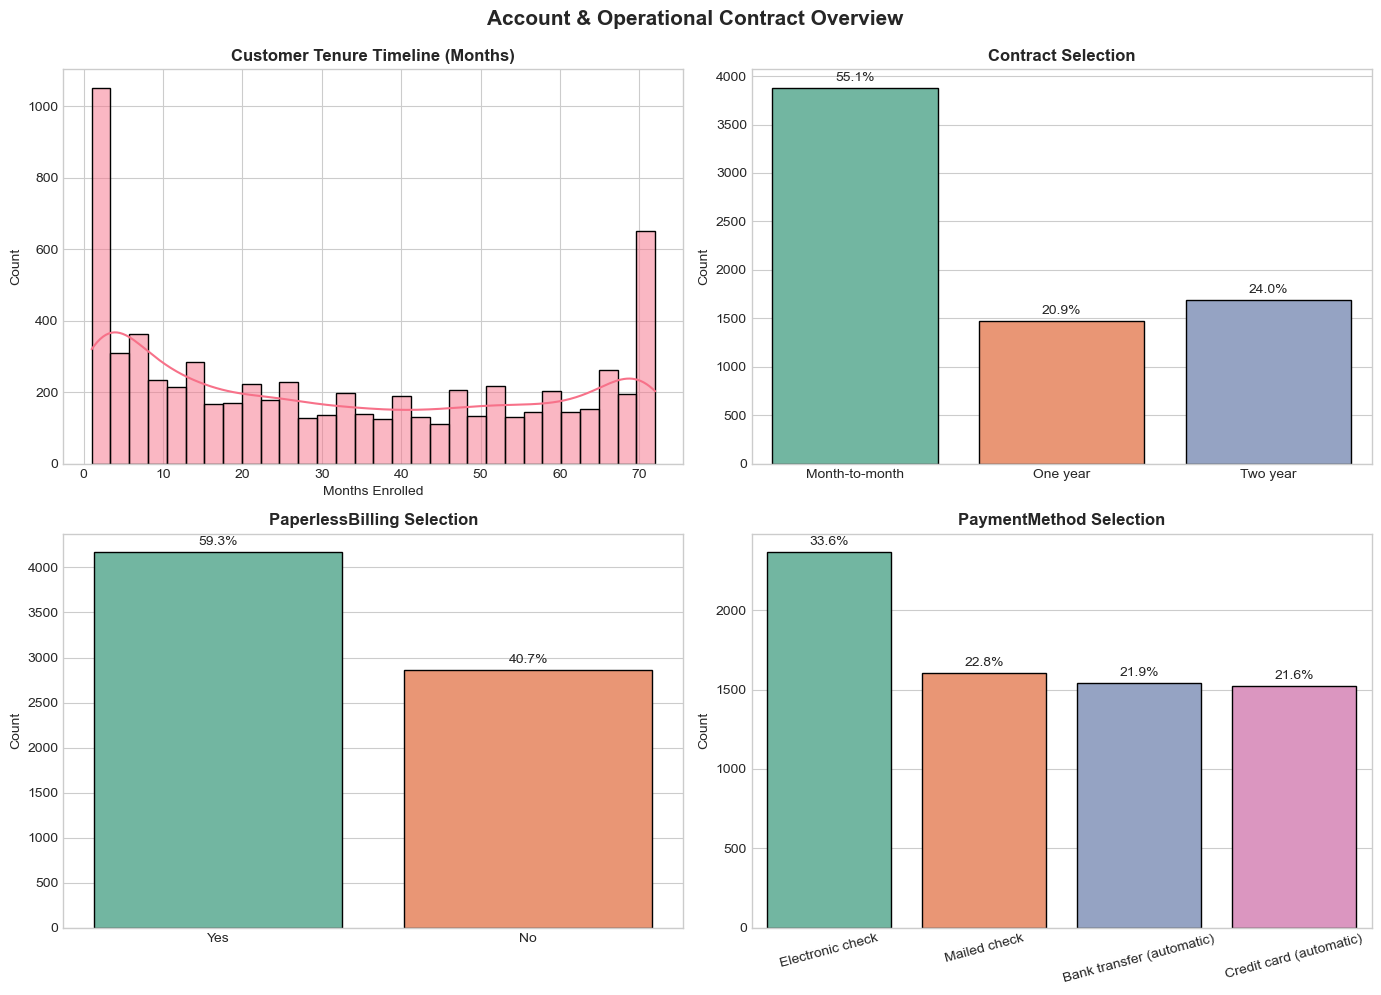

In [13]:
account_features = ["tenure", "Contract", "PaperlessBilling", "PaymentMethod"]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for ax, feature in zip(axes, account_features):
    if feature == "tenure":
        # Continuous feature logic
        sns.histplot(
            data=df,
            x=feature,
            kde=True,
            #color="skyblue",
            edgecolor="black",
            bins=30,
            ax=ax
        )
        ax.set_title("Customer Tenure Timeline (Months)", fontsize=12, fontweight='bold')
        ax.set_xlabel('Months Enrolled')
    else:
        # Categorical features logic
        sns.countplot(
            data=df,
            x=feature,
            hue=feature,
            palette="Set2",
            edgecolor="black",
            legend=False, 
            ax=ax
        )
        for container in ax.containers:
            ax.bar_label(
                container,
                labels=[f"{x / len(df) * 100:.1f}%" for x in container.datavalues],
                fontsize=10,
                padding=3
            )
        ax.set_title(f"{feature} Selection", fontsize=12, fontweight='bold')
        ax.set_xlabel('')
        
    ax.set_ylabel('Count')
    if feature == "PaymentMethod":
        ax.tick_params(axis='x', rotation=15) # Rotate longer payment naming conventions cleanly

fig.suptitle('Account & Operational Contract Overview', fontsize=15, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()


### Billing Feature Distributions
`MonthlyCharges` and `TotalCharges`, with mean/median reference lines to check for skew.

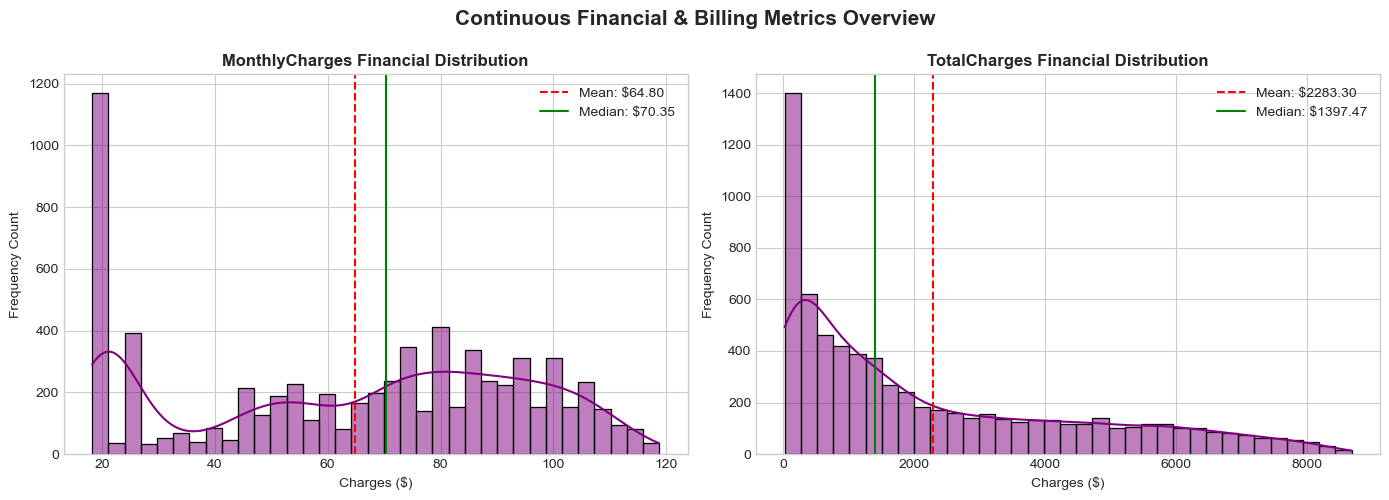

In [14]:
billing_features = ["MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
axes = axes.flatten()

for ax, feature in zip(axes, billing_features):
    sns.histplot(
        data=df,
        x=feature,
        kde=True,
        color="purple",
        edgecolor="black",
        bins=35,
        ax=ax
    )
    
    # Showcase statistical references right on top of the histograms
    mean_val = df[feature].mean()
    median_val = df[feature].median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: ${mean_val:.2f}')
    ax.axvline(median_val, color='green', linestyle='-', linewidth=1.5, label=f'Median: ${median_val:.2f}')
    
    ax.set_title(f"{feature} Financial Distribution", fontsize=12, fontweight='bold')
    ax.set_xlabel('Charges ($)')
    ax.set_ylabel('Frequency Count')
    ax.legend()

fig.suptitle('Continuous Financial & Billing Metrics Overview', fontsize=15, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()


## Bivariate Analysis: What Drives Churn?

Everything below cross-references features against `Churn` directly to surface the strongest
candidate predictors ahead of feature engineering.


In [17]:
# Map Churn to numeric for mathematical averages and correlations
df['Churn_Numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

### Family Status vs. Churn
Does having a partner and/or dependents relate to loyalty?

=== Family Status Interaction Cross-Tab (Churn Rates) ===
Churn                  No    Yes
Partner Dependents              
No      No          65.76  34.24
        Yes         78.55  21.45
Yes     No          74.59  25.41
        Yes         85.69  14.31


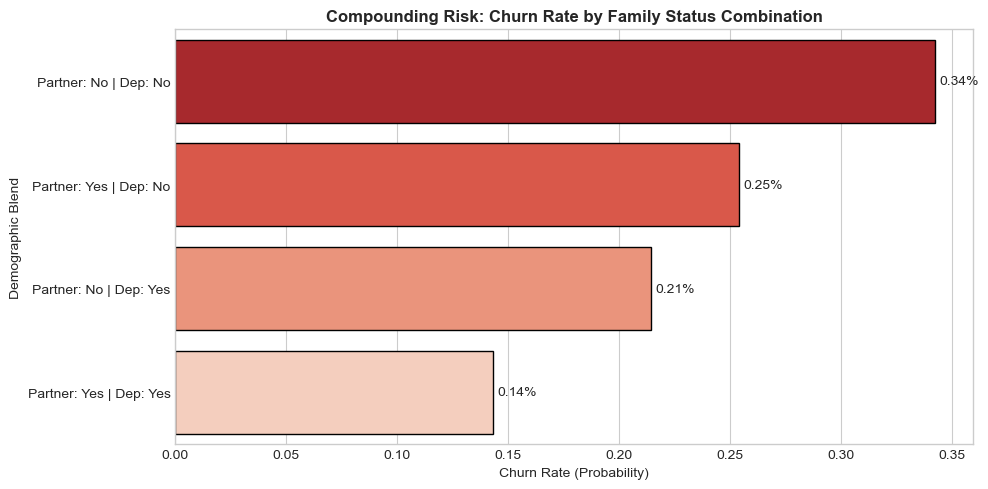

In [25]:
# Calculate multi-dimensional cross-tabulation for family structures
family_crosstab = pd.crosstab(
    index=[df['Partner'], df['Dependents']], 
    columns=df['Churn'], 
    normalize='index'
) * 100

print("=== Family Status Interaction Cross-Tab (Churn Rates) ===")
print(family_crosstab.round(2))

# Visualize the compounding effect of family status
plt.figure(figsize=(10, 5))
family_rates = df.groupby(['Partner', 'Dependents'])['Churn_Numeric'].mean().reset_index()
family_rates['Status_Combination'] = (
    "Partner: " + family_rates['Partner'].astype(str) + 
    " | Dep: " + family_rates['Dependents'].astype(str)
)
family_rates = family_rates.sort_values(by='Churn_Numeric', ascending=False)

sns.barplot(
    data=family_rates, 
    x='Churn_Numeric', 
    y='Status_Combination', 
    palette='Reds_r', 
    edgecolor='black'
)
plt.title('Compounding Risk: Churn Rate by Family Status Combination', fontsize=12, fontweight='bold')
plt.xlabel('Churn Rate (Probability)')
plt.ylabel('Demographic Blend')

for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.2f%%', padding=3)

plt.tight_layout()
plt.show()
# Insight: Customers with NO partner and NO dependents represent the highest compound risk segment.


**Summary:** churn rate ranges from **14.3%** (has partner **and** dependents) up to **34.2%**
(no partner, no dependents) — a ~20-point spread. Customers with no family ties in the household
are the highest-risk demographic segment, likely reflecting weaker switching costs / less
price sensitivity pressure from a shared household.


Quick reference: overall household composition (independent of churn).

In [26]:
pd.crosstab(df['Partner'], df['Dependents'], normalize='index')

Dependents,No,Yes
Partner,,
No,0.901347,0.098653
Yes,0.487179,0.512821


### Service Adoption, Bundling & Internet Type vs. Churn
Does having more add-on services (`Addon_Count`) correlate with retention? Does the type of internet connection matter?

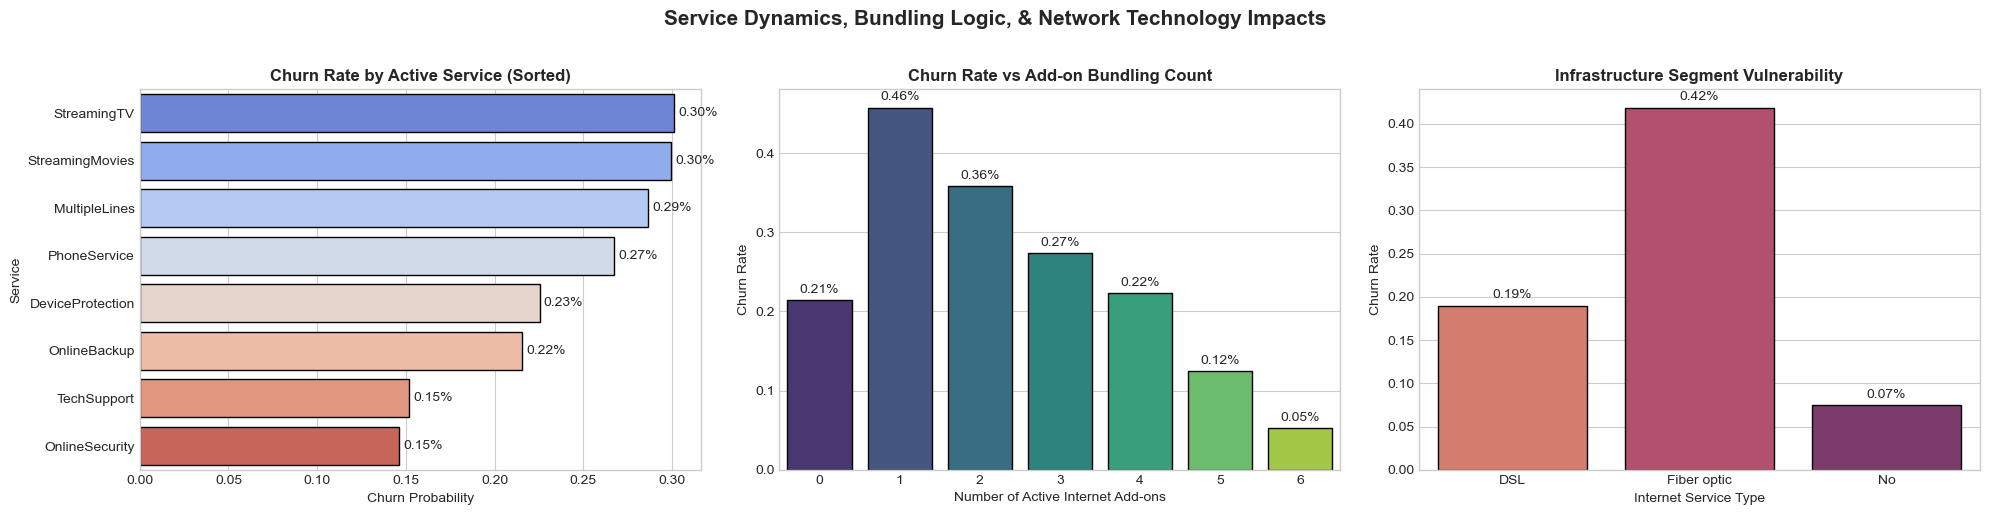

In [30]:
service_list = ["PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup", 
                "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

# 1. Calculate and Sort Churn Rates per individual service feature
service_churn_rates = {}
for service in service_list:
    # Filter for options where users actively have the service active ('Yes')
    rate = df[df[service] == 'Yes']['Churn_Numeric'].mean()
    service_churn_rates[service] = rate

sorted_services = pd.DataFrame(list(service_churn_rates.items()), columns=['Service', 'ChurnRate']).sort_values(by='ChurnRate', ascending=False)

# 2. Service Bundling Logic (Count of active internet add-ons)
addons = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['Addon_Count'] = (df[addons] == 'Yes').sum(axis=1)

# Set up multi-panel structural visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot A: Sorted Churn Rates by Active Feature
sns.barplot(data=sorted_services, x='ChurnRate', y='Service', ax=axes[0], palette='coolwarm', edgecolor='black')
axes[0].set_title('Churn Rate by Active Service (Sorted)', fontweight='bold')
axes[0].set_xlabel('Churn Probability')
for c in axes[0].containers: axes[0].bar_label(c, fmt='%.2f%%', padding=3)

# Plot B: Bundling Effect (Add-on counts vs Churn)
sns.barplot(data=df, x='Addon_Count', y='Churn_Numeric', ax=axes[1], palette='viridis', ci=None, edgecolor='black')
axes[1].set_title('Churn Rate vs Add-on Bundling Count', fontweight='bold')
axes[1].set_xlabel('Number of Active Internet Add-ons')
axes[1].set_ylabel('Churn Rate')
for c in axes[1].containers: axes[1].bar_label(c, fmt='%.2f%%', padding=3)

# Plot C: Infrastructure Type Focus (Checklist Warning: Fiber Optic anomalies)
sns.barplot(data=df, x='InternetService', y='Churn_Numeric', ax=axes[2], palette='flare', ci=None,edgecolor='black')
axes[2].set_title('Infrastructure Segment Vulnerability', fontweight='bold')
axes[2].set_xlabel('Internet Service Type')
axes[2].set_ylabel('Churn Rate')
for c in axes[2].containers: axes[2].bar_label(c, fmt='%.2f%%', padding=3)

plt.suptitle('Service Dynamics, Bundling Logic, & Network Technology Impacts', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Summary:** customers with **zero add-ons** churn at a much higher rate than those with several
bundled services — bundling appears to increase stickiness. Separately, **Fiber optic** customers
show a visibly higher churn rate than DSL or no-internet customers, despite being a premium/newer
offering — worth flagging as a service-quality or price-sensitivity signal to dig into further.


### Tenure Lifecycle & Contract Risk
How does churn risk evolve across a customer's lifetime, and how does contract type interact with tenure cohort?

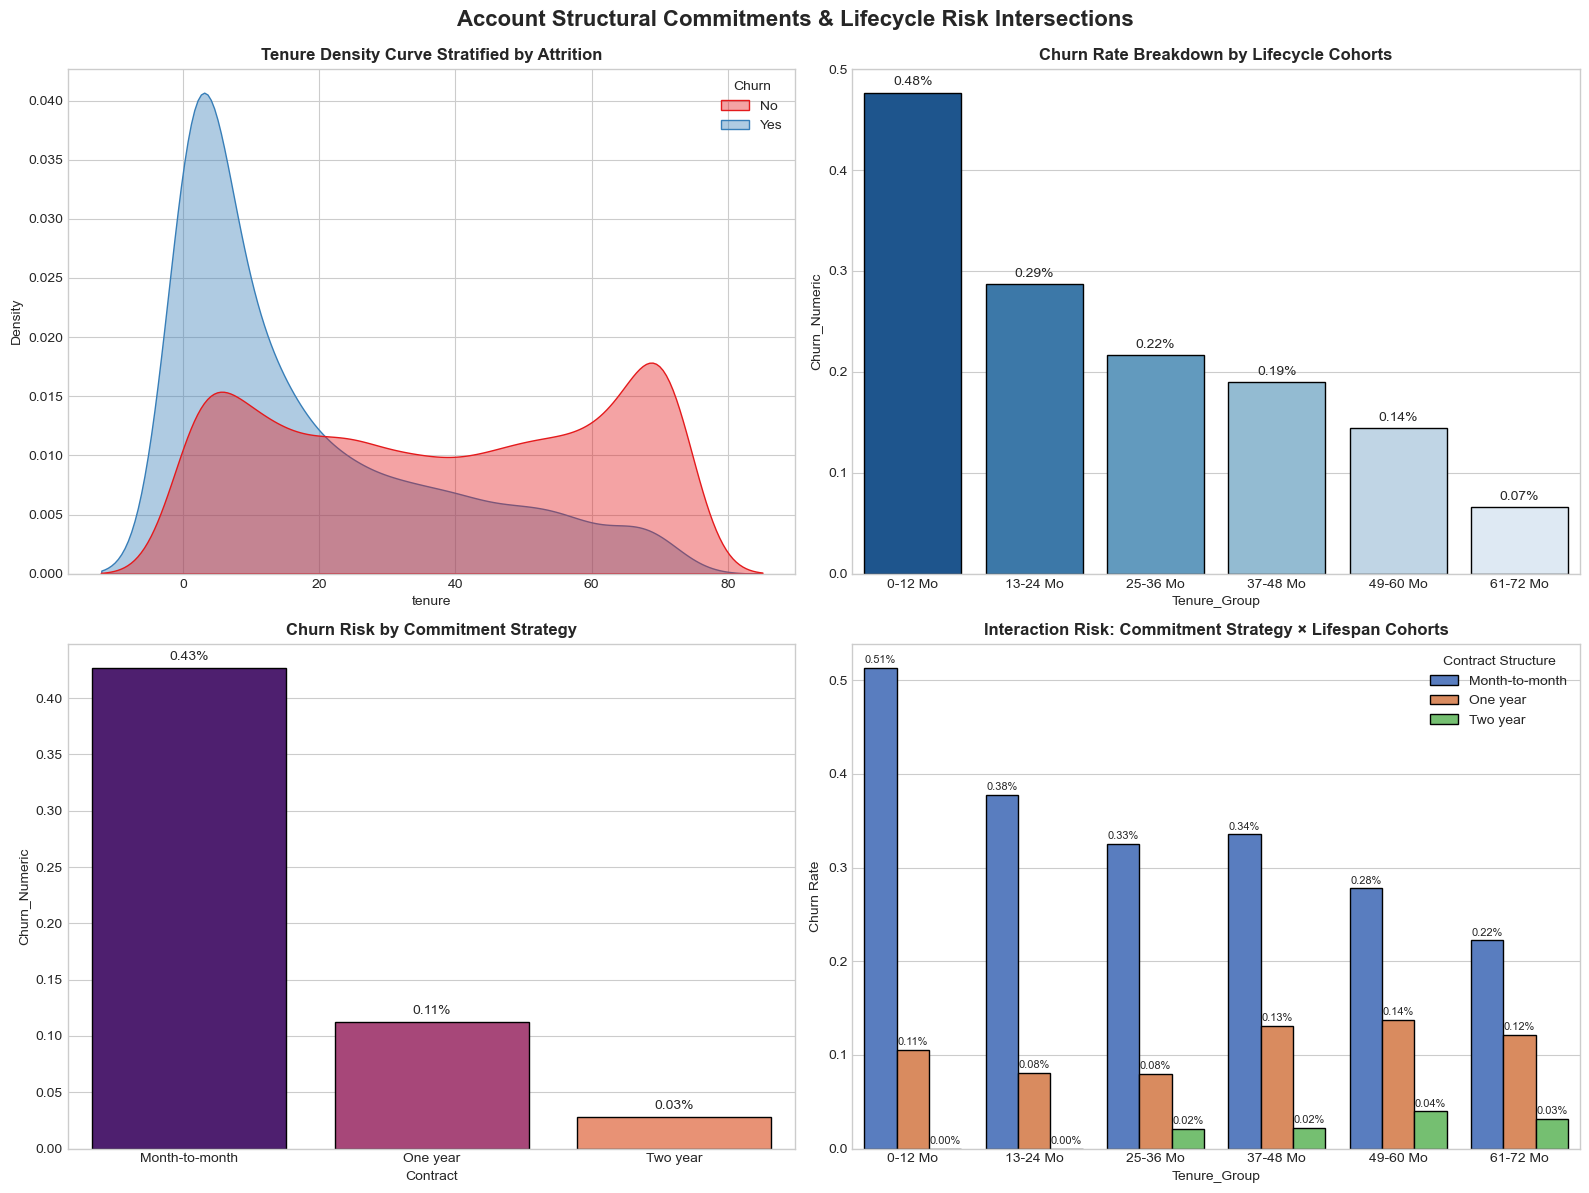

In [33]:
# 1. Bin Tenure into logical operational lifecycle groups
tenure_bins = [0, 12, 24, 36, 48, 60, 72]
tenure_labels = ['0-12 Mo', '13-24 Mo', '25-36 Mo', '37-48 Mo', '49-60 Mo', '61-72 Mo']
df['Tenure_Group'] = pd.cut(df['tenure'], bins=tenure_bins, labels=tenure_labels, include_lowest=True)

# 2. Setup Multi-Panel Account Matrix
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top Left: Continuous Tenure Density splits
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False, ax=axes[0, 0], palette='Set1', alpha=0.4)
axes[0, 0].set_title('Tenure Density Curve Stratified by Attrition', fontweight='bold')

# Top Right: Tenure Cohort Churn Probabilities
sns.barplot(data=df, x='Tenure_Group', y='Churn_Numeric', ax=axes[0, 1], palette='Blues_r', edgecolor='black', ci=None)
axes[0, 1].set_title('Churn Rate Breakdown by Lifecycle Cohorts', fontweight='bold')
for c in axes[0, 1].containers: axes[0, 1].bar_label(c, fmt='%.2f%%', padding=3)

# Bottom Left: Operational Frameworks (Contract & Billing Adjustments)
contract_billing = df.groupby('Contract')['Churn_Numeric'].mean().reset_index()
sns.barplot(data=contract_billing, x='Contract', y='Churn_Numeric', ax=axes[1, 0], palette='magma', edgecolor='black')
axes[1, 0].set_title('Churn Risk by Commitment Strategy', fontweight='bold')
for c in axes[1, 0].containers: axes[1, 0].bar_label(c, fmt='%.2f%%', padding=3)

# Bottom Right: Interaction Matrix (Contract Structure × Tenure Lifecycle Spikes)
interaction_data = df.groupby(['Tenure_Group', 'Contract'])['Churn_Numeric'].mean().reset_index()
sns.barplot(data=interaction_data, x='Tenure_Group', y='Churn_Numeric', hue='Contract', ax=axes[1, 1], palette='muted', edgecolor='black')
axes[1, 1].set_title('Interaction Risk: Commitment Strategy × Lifespan Cohorts', fontweight='bold')
axes[1, 1].set_ylabel('Churn Rate')
axes[1, 1].legend(title='Contract Structure')
for c in axes[1, 1].containers: axes[1, 1].bar_label(c, fmt='%.2f%%', padding=2, fontsize=8)

plt.suptitle('Account Structural Commitments & Lifecycle Risk Intersections', fontsize=16, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()


### Contract Type & Tenure: Closer Look

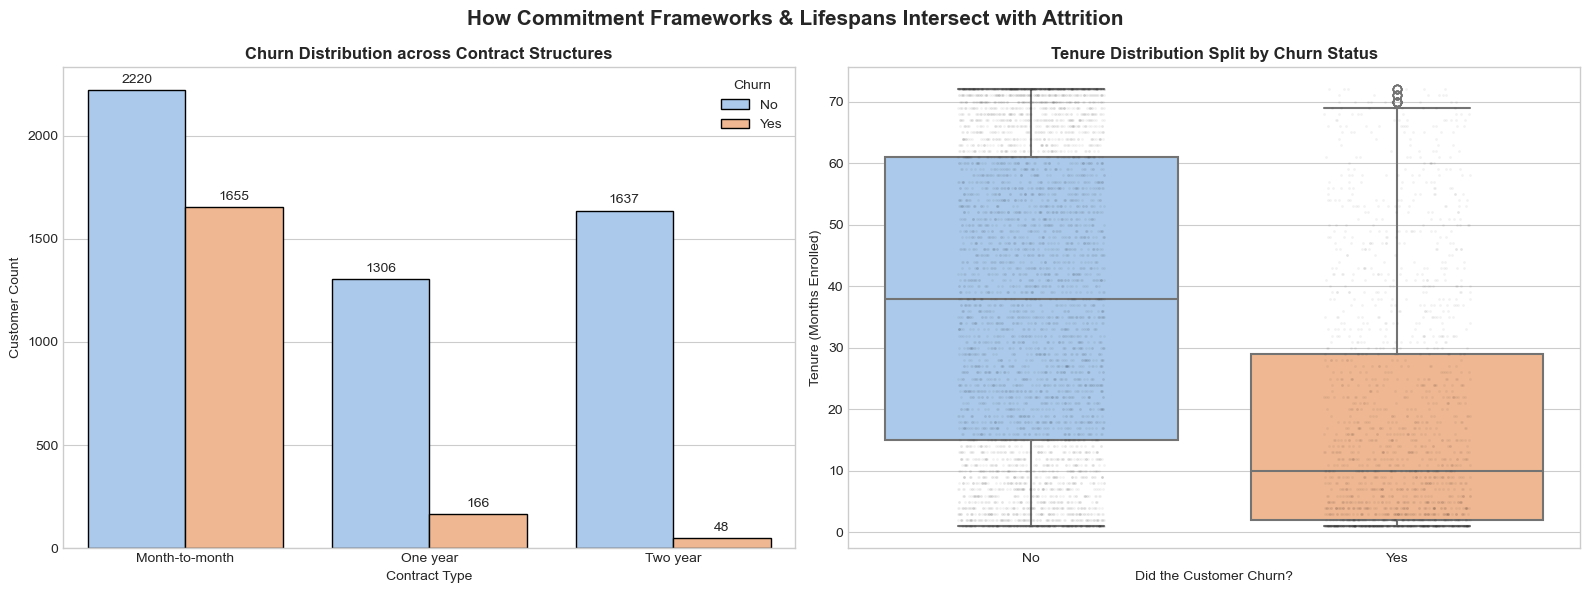

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Contract vs Churn Breakdown
sns.countplot(
    data=df,
    x='Contract',
    hue='Churn',
    palette='pastel',
    edgecolor='black',
    ax=axes[0]
)
axes[0].set_title('Churn Distribution across Contract Structures', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Customer Count')

# Calculate percentages within each contract type to make comparison balanced
for container in axes[0].containers:
    axes[0].bar_label(container, padding=3, fontsize=10)

# 2. Tenure vs Churn Breakdown (Boxplot & Distribution Split)
sns.boxplot(
    data=df,
    x='Churn',
    y='tenure',
    palette='pastel',
    ax=axes[1],
    linewidth=1.5
)
# Overlay a swarm or strip plot safely to observe underlying density shifts if necessary
sns.stripplot(data=df, x='Churn', y='tenure', color='black', alpha=0.05, size=2, jitter=0.2, ax=axes[1])

axes[1].set_title('Tenure Distribution Split by Churn Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Did the Customer Churn?')
axes[1].set_ylabel('Tenure (Months Enrolled)')

plt.suptitle('How Commitment Frameworks & Lifespans Intersect with Attrition', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()
# Insight: Month-to-month contracts contain the massive bulk of churners. 
# The boxplot shows the median tenure for churned users is significantly lower than retained users.


### Payment Method within Contract Segments

=== Proportion % of Payment Methods inside Contract Tiers ===
PaymentMethod   Bank transfer (automatic)  Credit card (automatic)  \
Contract                                                             
Month-to-month                      15.20                    14.01   
One year                            26.56                    27.04   
Two year                            33.35                    34.42   

PaymentMethod   Electronic check  Mailed check  
Contract                                        
Month-to-month             47.74         23.05  
One year                   23.57         22.83  
Two year                    9.97         22.26  


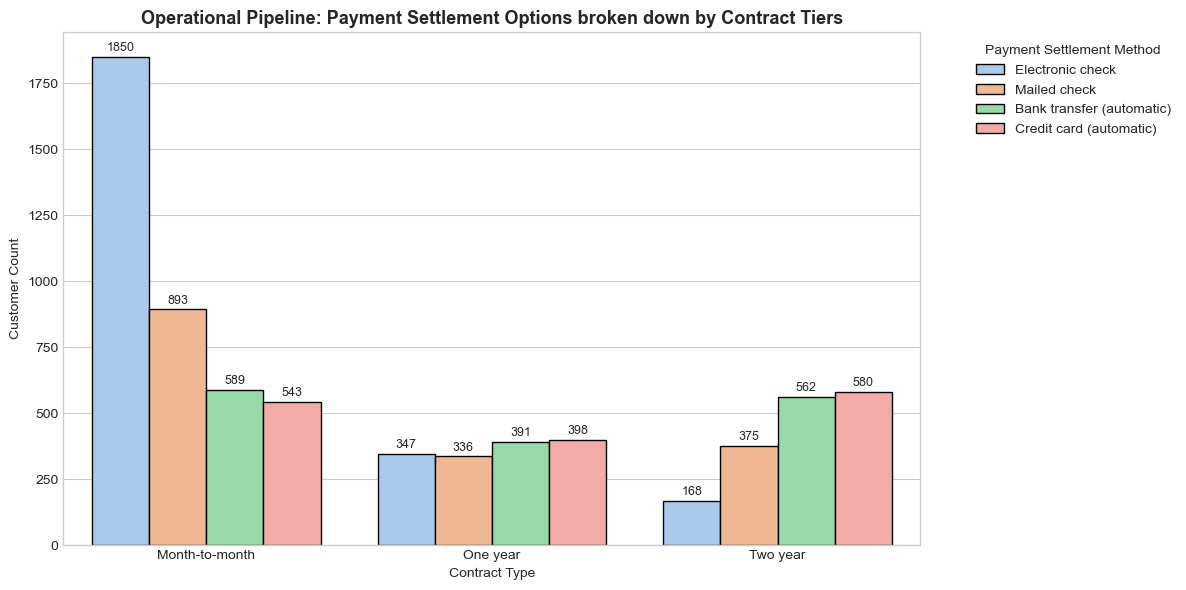

In [37]:
# Calculate a normalized distribution layout of payment methods inside contract segments
contract_payment_matrix = pd.crosstab(
    df['Contract'], 
    df['PaymentMethod'], 
    normalize='index'
) * 100

print("=== Proportion % of Payment Methods inside Contract Tiers ===")
print(contract_payment_matrix.round(2))

# Visualize operational distribution channels
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x='Contract',
    hue='PaymentMethod',
    palette='pastel',
    edgecolor='black'
)

plt.title('Operational Pipeline: Payment Settlement Options broken down by Contract Tiers', fontsize=13, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Customer Count')
plt.legend(title='Payment Settlement Method', bbox_to_anchor=(1.05, 1), loc='upper left')

# Render count labels over columns
for container in plt.gca().containers:
    plt.gca().bar_label(container, padding=2, fontsize=9)

plt.tight_layout()
plt.show()
# Insight: A massive volume of Month-to-Month accounts utilize "Electronic check". 
# This highlights exactly why your toxic cluster (Month-to-Month + Electronic Check) accumulates so heavily.


**Summary:** **47.7%** of Month-to-month customers pay via Electronic check, vs. only **10.0%**
of Two-year contract customers. Combined with the contract-type churn breakdown above, this
confirms a "toxic cluster": **Month-to-month + Electronic check** customers are both the largest
segment and the highest-risk one — a strong candidate for a combined feature or targeted retention
campaign.


### Data Quality Audit: Billing Consistency
Sanity-check whether `TotalCharges` roughly equals `MonthlyCharges × tenure`, and look at the raw charge distributions split by churn.

⚠️ Data Audit Flag: Detected 2322 account rows violating TotalCharges ≈ MonthlyCharges × Tenure formula.


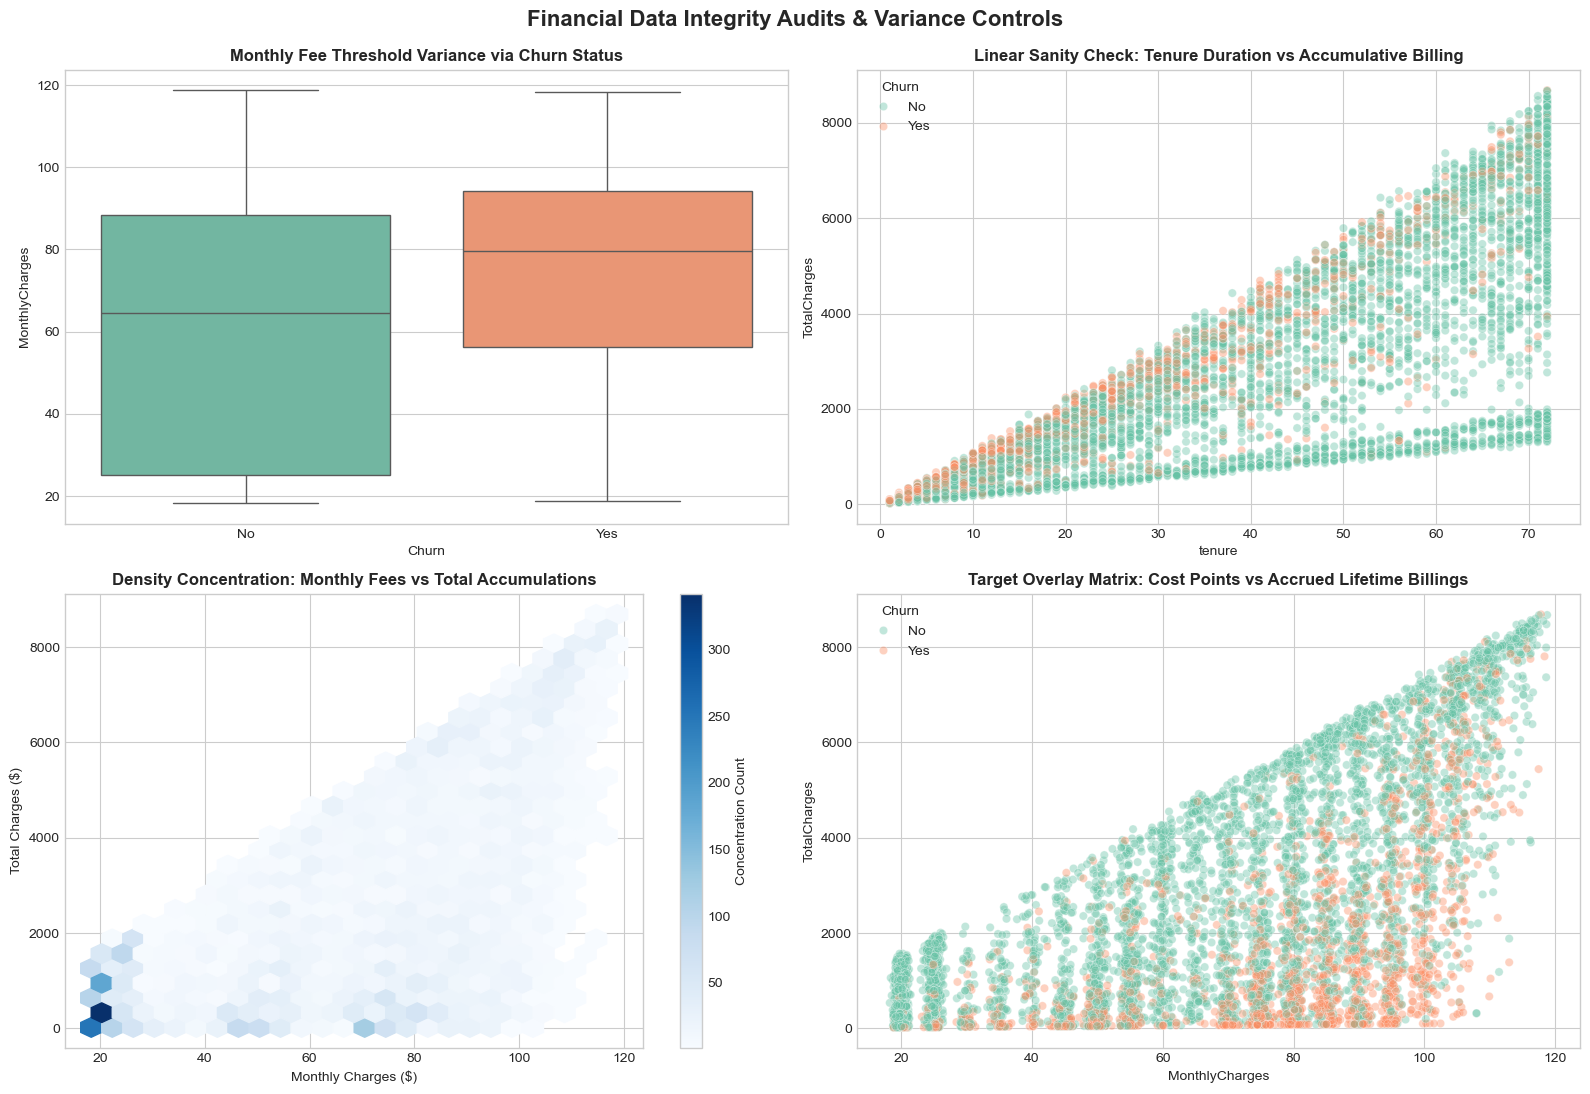

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Top Left: Financial Spread Deviations
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Monthly Fee Threshold Variance via Churn Status', fontweight='bold')

# Top Right: Expected Revenue Multipliers vs Actual System Output (Sanity Check)
df['Expected_TotalCharges'] = df['MonthlyCharges'] * df['tenure']
df['Billing_Discrepancy'] = (df['TotalCharges'] - df['Expected_TotalCharges']).abs()

# Establish a tolerance variance ($50 cushion for mid-contract shifts/promotions)
anomalies = df[df['Billing_Discrepancy'] > 50]
print(f"⚠️ Data Audit Flag: Detected {len(anomalies)} account rows violating TotalCharges ≈ MonthlyCharges × Tenure formula.")

sns.scatterplot(data=df, x='tenure', y='TotalCharges', hue='Churn', alpha=0.4, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Linear Sanity Check: Tenure Duration vs Accumulative Billing', fontweight='bold')

# Bottom Row: Hexbin Dense Volume Map vs Target Colorization Mapping
# Left Bottom - Volume clustering density map
hb = axes[1, 0].hexbin(df['MonthlyCharges'], df['TotalCharges'], gridsize=25, cmap='Blues', mincnt=1)
fig.colorbar(hb, ax=axes[1, 0], label='Concentration Count')
axes[1, 0].set_title('Density Concentration: Monthly Fees vs Total Accumulations', fontweight='bold')
axes[1, 0].set_xlabel('Monthly Charges ($)')
axes[1, 0].set_ylabel('Total Charges ($)')

# Right Bottom - Churn context target view
sns.scatterplot(data=df, x='MonthlyCharges', y='TotalCharges', hue='Churn', alpha=0.4, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Target Overlay Matrix: Cost Points vs Accrued Lifetime Billings', fontweight='bold')

plt.suptitle('Financial Data Integrity Audits & Variance Controls', fontsize=16, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()


**Summary:** **2,322 rows** (~33% of the dataset) deviate from the expected
`TotalCharges ≈ MonthlyCharges × tenure` relationship by more than $50 — most plausibly explained
by mid-contract price changes, promotions, or add-on upgrades/downgrades rather than a data error,
but worth keeping in mind: `TotalCharges` isn't a perfectly clean derived field.


### Correlation Matrix: Key Numeric Relationships
Bring together the strongest categorical signals (encoded as flags) alongside the numeric fields to see how they relate to each other and to churn.

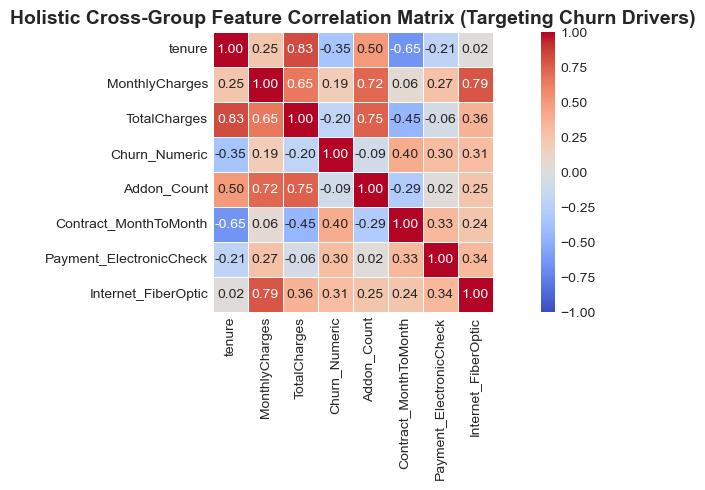

In [23]:
# Isolate all continuous elements and map basic strings to rapid dummy vectors for the matrix
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Numeric', 'Addon_Count']

# Append key strong structural predictors via fast OHE maps to check correlations
correlation_set = df[numeric_cols].copy()
correlation_set['Contract_MonthToMonth'] = df['Contract'].apply(lambda x: 1 if x == 'Month-to-month' else 0)
correlation_set['Payment_ElectronicCheck'] = df['PaymentMethod'].apply(lambda x: 1 if x == 'Electronic check' else 0)
correlation_set['Internet_FiberOptic'] = df['InternetService'].apply(lambda x: 1 if x == 'Fiber optic' else 0)

# Compute Pearson Correlation Product Matrix
matrix = correlation_set.corr()

plt.figure(figsize=(10, 5))
sns.heatmap(
    matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f', 
    linewidths=0.5, 
    vmin=-1, 
    vmax=1,
    square=True
)
plt.title('Holistic Cross-Group Feature Correlation Matrix (Targeting Churn Drivers)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Summary:** `tenure` shows the strongest (negative) relationship with churn among the numeric
fields, `Contract_MonthToMonth` and `Payment_ElectronicCheck` both correlate positively with churn,
and `Addon_Count` correlates negatively — consistent with everything found above. `TotalCharges` is,
unsurprisingly, highly correlated with `tenure` (it's a near-product of tenure and monthly spend),
which is useful to know before feeding both into a linear model.


## Feature Category Reference

- **Demographic:** `gender`, `SeniorCitizen`, `Partner`, `Dependents`
- **Service:** `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`,
  `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`
- **Account:** `tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod`
- **Billing:** `MonthlyCharges`, `TotalCharges`

## Key Takeaways

1. **Contract type is the single strongest driver** — Month-to-month customers churn far more than
   one- or two-year contract holders.
2. **Tenure and churn are inversely related** — risk is highest in the first year and drops sharply
   as customers stay longer.
3. **Payment method compounds contract risk** — Electronic check + Month-to-month is the highest-risk
   combination, and it's also one of the largest customer segments.
4. **Fiber optic internet customers churn more** than DSL or no-internet customers, despite being a
   premium tier — worth investigating (price? service quality? competitive market?).
5. **Service bundling reduces churn** — customers with more active add-ons (security, backup, tech
   support, streaming) are stickier.
6. **Household composition matters** — customers without a partner or dependents churn at nearly
   2.5x the rate of those with both.
7. `TotalCharges` isn't a clean product of `tenure × MonthlyCharges` for about a third of rows —
   keep this in mind rather than assuming it's purely derived.

**Next step:** these findings map directly onto the engineered features in
`churn_model_pipeline.ipynb` (`contract_risk_score`, `is_electronic_check`, `num_services`,
`has_family`, `tenure_group`, etc.) — this EDA is effectively the justification for that feature set.
